In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
import argparse
from nnfabrik.builder import get_data, get_trainer

from modified_neuralpredictors.create_model import stacked_core_full_gauss_readout
from modified_neuralpredictors.wandb_trainer import standard_trainer


random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = 'cuda:0'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

model_config = {
    'hidden_channels': 128, # original sensorium was 64ch
    'depth_separable': False,
    'use_avg_reg': False,
    'laplace_padding': None,
    'momentum': 0.75,
    'final_nonlinearity': True,
    'nonlinearity_type': 'AdaptiveELU',
    'pad_input': False,
    'stack': -1,
    'layers': 4,
    'input_kern': 11, #  original sensorium was 'input_kern': 9,
    'gamma_input': 6.3831, # this should not influence the performance based on previous experience
    
    'feature_reg_weight': 3, # this is the one I actually would like to tune!
    
    'hidden_kern': 7,
    'grid_mean_predictor': {
        'type': 'cortex',
        'input_dimensions': 2,
        'hidden_layers': 1,
        'hidden_features': 30,
        'final_tanh': True
    },
    
    'init_sigma': 0.1,
    'init_mu_range': 0.3,
    'gauss_type': 'full',
    'shifter': True,
    'batch_norm_scale': [True, True, True, False],
    'core_bias': [True, True, True, False],
    'regularizer_type': "adaptive_log_norm",
    'gamma_sigma' : 0.25,
}

model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
model.load_state_dict(torch.load('runs/base/exp1/model_weights.pth'))
model.to(device)

/srv/user/nathanpaul.soeding/private_neuropredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/srv/user/nathanpaul.soeding/private_neuropredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


FiringRateEncoder(
  (core): Stacked2dCore(
    (_input_weights_regularizer): LaplaceL2norm(
      (laplace): Laplace()
    )
    (features): Sequential(
      (layer0): Sequential(
        (conv): Conv2d(4, 128, kernel_size=(11, 11), stride=(1, 1), bias=False)
        (norm): BatchNorm2d(128, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
        (nonlin): AdaptiveELU()
      )
      (layer1): Sequential(
        (conv): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
        (norm): BatchNorm2d(128, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
        (nonlin): AdaptiveELU()
      )
      (layer2): Sequential(
        (conv): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
        (norm): BatchNorm2d(128, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
        (nonlin): AdaptiveELU()
      )
      (layer3): Sequential(
        (conv): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padd

In [2]:
num_batches = 5
key = data_keys[0]
iterator = iter(dataloaders['train'][key])

In [3]:
embeddings = model.readout[key].features.data.squeeze().cpu().T

In [4]:
pred_responses = []
model.eval()
for _ in range(num_batches):
    batch = next(iterator)
    img, _, _, pupil = batch
    pred = model(img, data_key=key, pupil_center=pupil)
    pred_responses.append(pred)
pred_responses = torch.cat(pred_responses).detach().cpu().T  # (num_neurons, num_images)

In [5]:
dists = (embeddings[None, :, :] - embeddings[:, None, :]).pow(2).sum(dim=-1).pow(0.5)

In [6]:
resp_cor = torch.corrcoef(pred_responses)

In [7]:
norm = torch.norm(embeddings, dim=1)
normalized_embeds = embeddings / norm[:, None]
cosine_sim = (
    (normalized_embeds[None, :, :] * normalized_embeds[:, None, :])
    .sum(dim=-1)
)

In [8]:
i, j = np.tril_indices(resp_cor.shape[0], k=-1)
resp_cor = resp_cor[i, j]
dists = dists[i, j]
cosine_sim = cosine_sim[i, j]

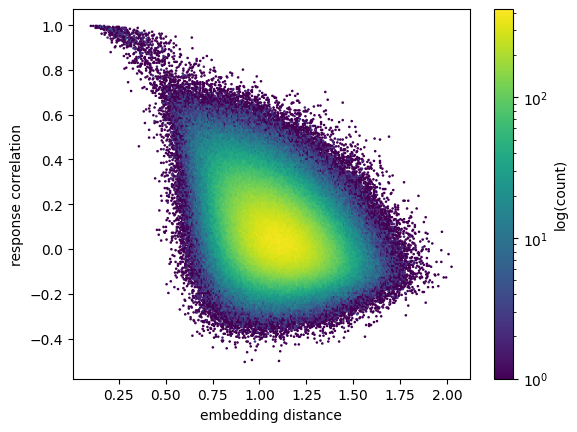

In [9]:
idcs = np.random.permutation(resp_cor.shape[0])[:2000000]
plt.hexbin(
    dists[idcs],
    resp_cor[idcs],
    gridsize=300,
    bins='log'   # log density is crucial
)
plt.colorbar(label='log(count)')
plt.xlabel('embedding distance')
plt.ylabel('response correlation')
plt.savefig('plots/response_corr_vs_emb_dist.png')
plt.show()

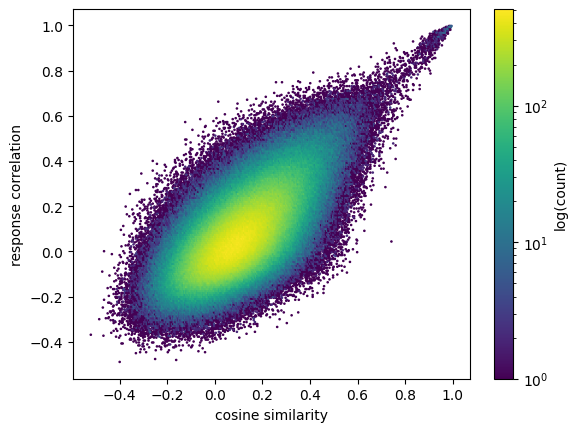

In [10]:
idcs = np.random.permutation(resp_cor.shape[0])[:2000000]
plt.hexbin(
    cosine_sim[idcs],
    resp_cor[idcs],
    gridsize=300,
    bins='log'   # log density is crucial
)
plt.colorbar(label='log(count)')
plt.xlabel('cosine similarity')
plt.ylabel('response correlation')
plt.savefig('plots/response_corr_vs_cosine_sim.png')
plt.show()

In [11]:
cosine_sim0 = cosine_sim - cosine_sim.mean()
resp_cor0 = resp_cor - resp_cor.mean()
correlation = (
    cosine_sim0 @ resp_cor0) / (torch.norm(cosine_sim0) * torch.norm(resp_cor0)
)
print(correlation)

tensor(0.6636)


In [12]:
all_embs = []
for key in data_keys:
    all_embs.append(
        model.readout[key].features.data.cpu().squeeze().T
    )
all_embs = torch.cat(all_embs)

In [13]:
X = all_embs
Xc = X - X.mean(dim=0)
C = Xc.T @ Xc / (Xc.shape[0] - 1)

eigvals = torch.linalg.eigvalsh(C).flip(0)

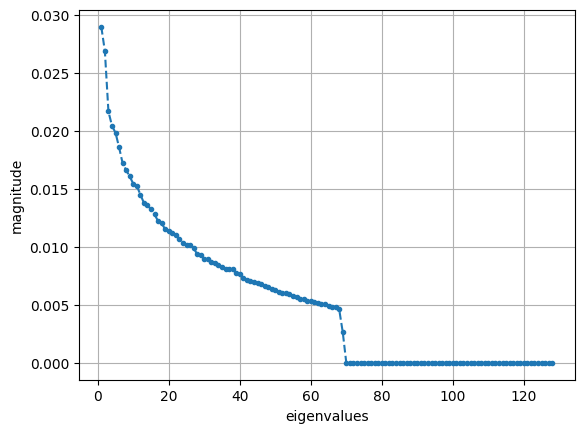

In [15]:
plt.plot(np.arange(len(eigvals)) + 1, eigvals, ls='--', marker='.')
plt.grid()
plt.xlabel('eigenvalues')
plt.ylabel('magnitude')
plt.savefig('plots/eigvals.png')
plt.show()